In [1]:
import pandas as pd
import sqlite3

## download data from checking table

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
checker_date = pd.read_sql(
    '''
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
''', conn, parse_dates='timestamp'
)
checker_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3207 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 25.2 KB


## group the data by date and count the number of commits in each period of the day

In [4]:
checker_date['night'] = checker_date.timestamp.apply(lambda date: 1 if date.hour < 4 else 0)
checker_date['morning'] = checker_date.timestamp.apply(lambda date: 1 if 4 <= date.hour < 10 else 0)
checker_date['afternoon'] = checker_date.timestamp.apply(lambda date: 1 if 10 <= date.hour < 17 else 0)
checker_date['evening'] = checker_date.timestamp.apply(lambda date: 1 if 17 <= date.hour < 24 else 0)

In [5]:
checker_date

,timestamp,night,morning,afternoon,evening
0,2020-04-17 05:19:02.744528,0,1,0,0
1,2020-04-17 05:22:35.249331,0,1,0,0
2,2020-04-17 05:22:45.549397,0,1,0,0
3,2020-04-17 05:34:14.691200,0,1,0,0
4,2020-04-17 05:34:24.422370,0,1,0,0
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,0,0,0,1
3203,2020-05-21 20:22:41.785725,0,0,0,1
3204,2020-05-21 20:22:41.877806,0,0,0,1
3205,2020-05-21 20:37:00.129678,0,0,0,1


In [11]:
grouped_data = checker_date.groupby(checker_date.timestamp.dt.date).sum(numeric_only=True)
grouped_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2020-04-17 to 2020-05-21
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   night      35 non-null     int64
 1   morning    35 non-null     int64
 2   afternoon  35 non-null     int64
 3   evening    35 non-null     int64
dtypes: int64(4)
memory usage: 1.4+ KB


## create graph of bar style

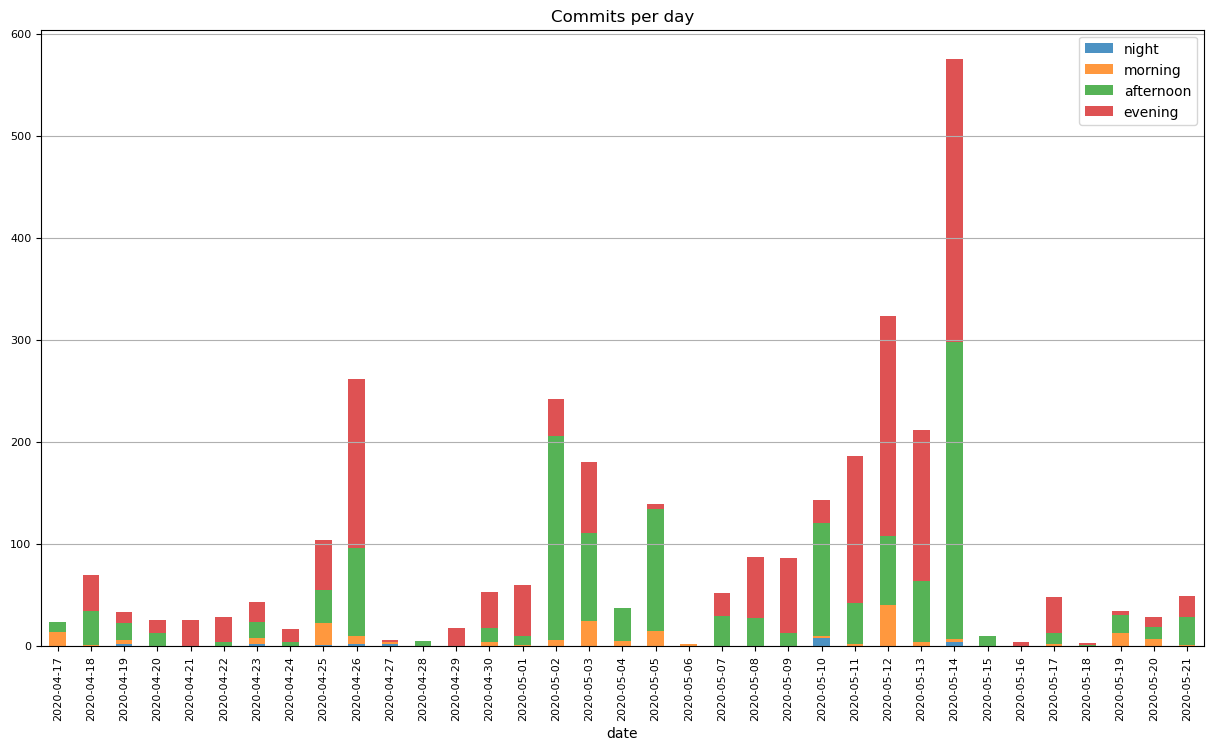

In [7]:
bar_graph = grouped_data.plot(kind='bar',
                  figsize=(15,8),
                  fontsize=8,
                  rot = 90,
                  title = 'Commits per day',
                  xlabel='date',
                  stacked=True,
                  alpha=0.8
                  )
bar_graph.grid(axis='y')

In [8]:
grouped_data.sum()

night          21
morning       184
afternoon    1391
evening      1611
dtype: int64

## When do our users usually commit the labs: in night, morning, afternoon, or evening?
## The answer is: afternoon and evening.

In [9]:
grouped_data[grouped_data.evening > grouped_data.afternoon].sum(axis=1).idxmax()

datetime.date(2020, 5, 12)

## Day has the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon ?
## Answer is - 2020-05-12	

In [10]:
conn.close()